In [2]:
# import data and libraries
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("US-National-Parks_Use_1979-2023_By-Month.csv")

In [9]:
# explore the data

data.head()

,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,TentCampers,RVCampers,Backcountry
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,1,6011,15252,102,13,0
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,2,5243,13776,53,8,0
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,3,11165,15252,176,37,0
3,Acadia NP,ACAD,National Park,Northeast,ME,1979,4,219351,37657,1037,459,0
4,Acadia NP,ACAD,National Park,Northeast,ME,1979,5,339416,50616,3193,1148,0


In [10]:
# group by park and year to see total visits per year
yearly_recreation_data = data.groupby(['ParkName', 'Year'])['RecreationVisits'].sum().reset_index()

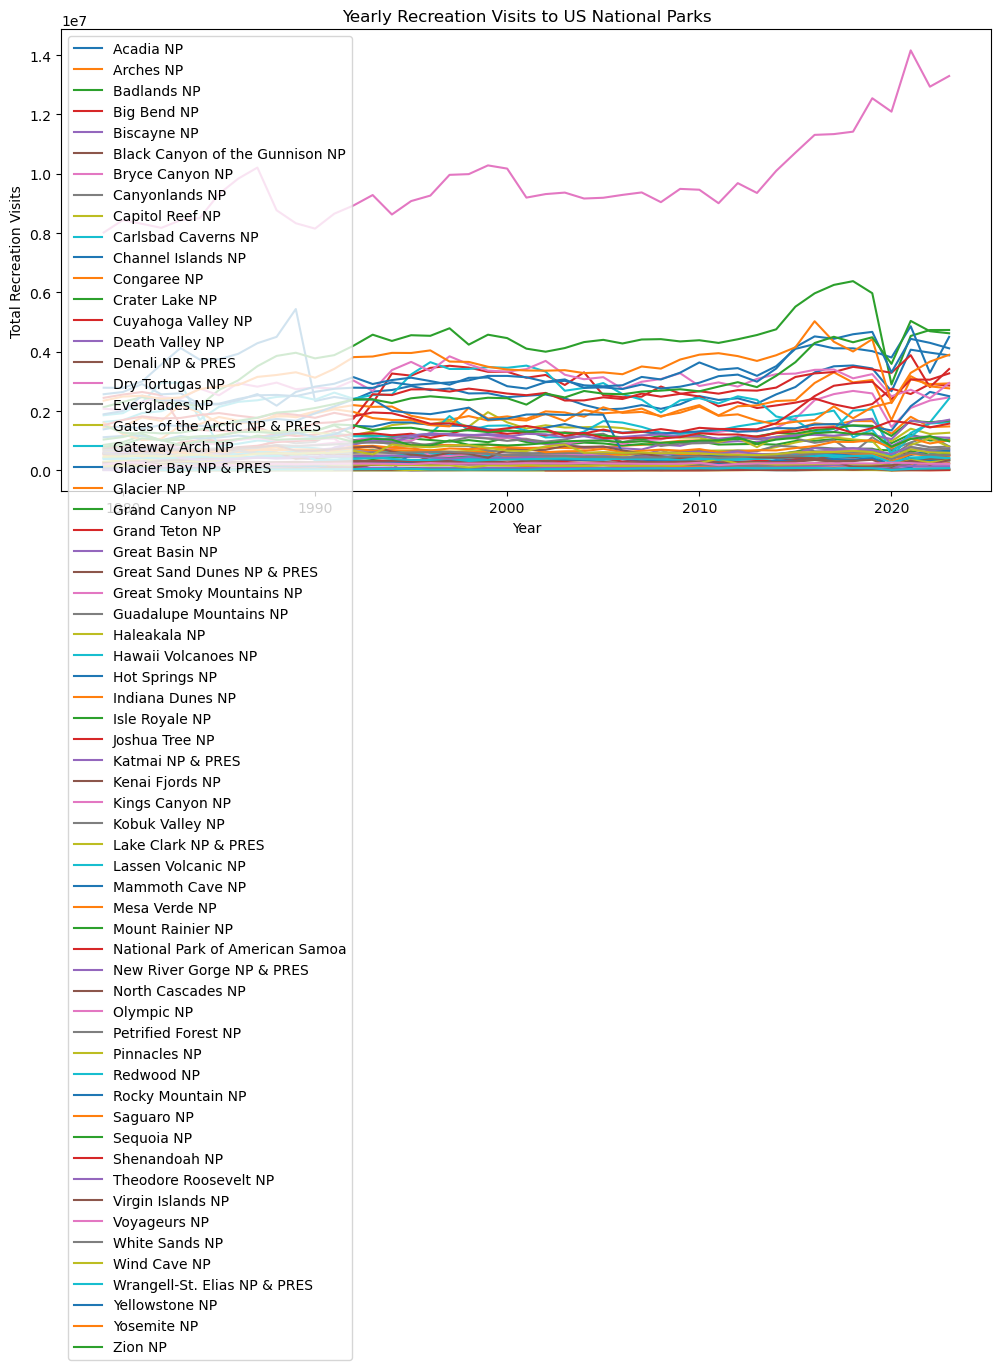

In [11]:
# plot!


plt.figure(figsize=(12, 6))
for park in yearly_recreation_data['ParkName'].unique():
    park_data = yearly_recreation_data[yearly_recreation_data['ParkName'] == park]
    plt.plot(park_data['Year'], park_data['RecreationVisits'], label=park)  

plt.xlabel('Year')
plt.ylabel('Total Recreation Visits')
plt.title('Yearly Recreation Visits to US National Parks')
plt.legend()
plt.show()

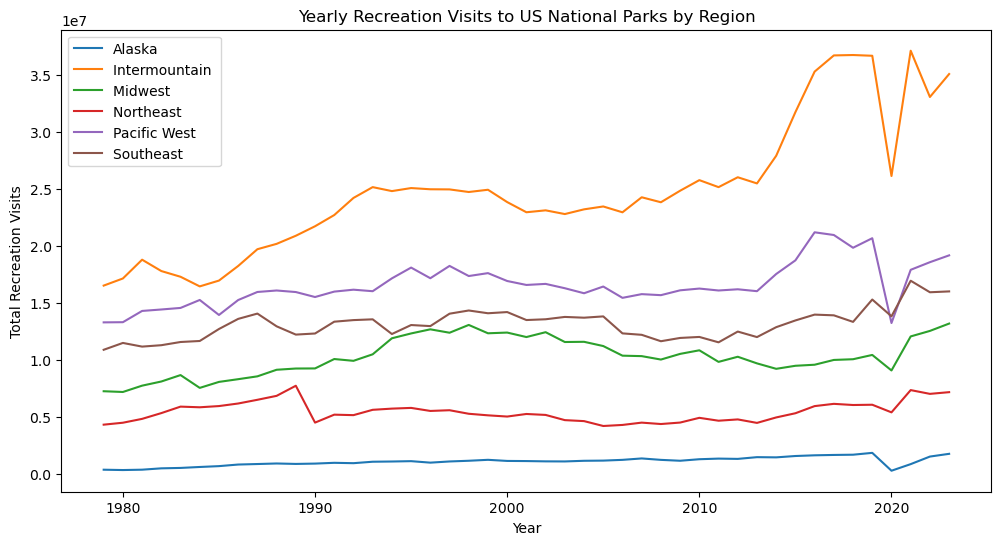

In [12]:
# is there a regional difference in total (recreation) visits over the years?

# group by region
region_yearly_data = data.groupby(['Region', 'Year'])['RecreationVisits'].sum().reset_index()
# plot
plt.figure(figsize=(12, 6))
for region in region_yearly_data['Region'].unique():   
    region_data = region_yearly_data[region_yearly_data['Region'] == region]
    plt.plot(region_data['Year'], region_data['RecreationVisits'], label=region)
plt.xlabel('Year')
plt.ylabel('Total Recreation Visits')
plt.title('Yearly Recreation Visits to US National Parks by Region')
plt.legend()
plt.show()

In [13]:
# which parks bounced back the fastest after the pandemic?
pandemic_data = yearly_recreation_data[yearly_recreation_data['Year'] >= 2019]
pandemic_data_pivot = pandemic_data.pivot(index='Year', columns='ParkName', values='RecreationVisits')  

# use percentage of 2019 visits to measure recovery
pandemic_data_pivot = pandemic_data_pivot.div(pandemic_data_pivot.loc[2019]) * 100  



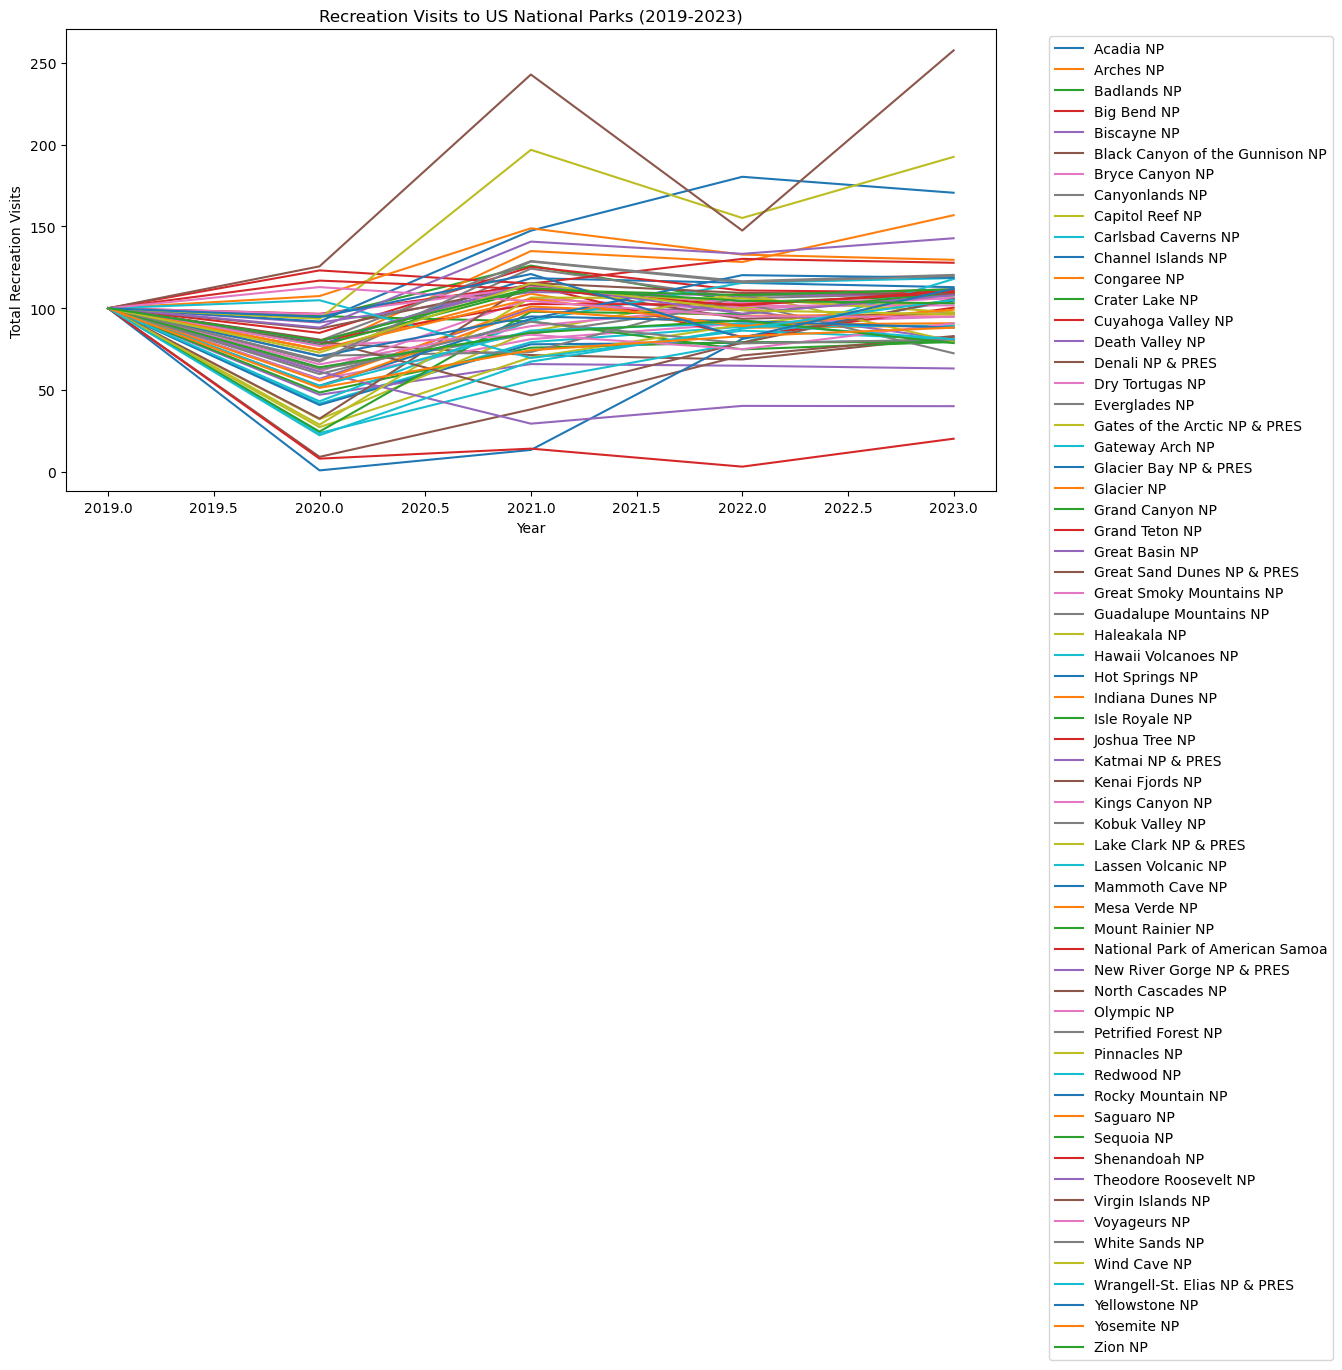

In [14]:
# plot pandemic recovery
pandemic_data_pivot.plot(figsize=(12, 6))
plt.xlabel('Year')
plt.ylabel('Total Recreation Visits')
plt.title('Recreation Visits to US National Parks (2019-2023)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


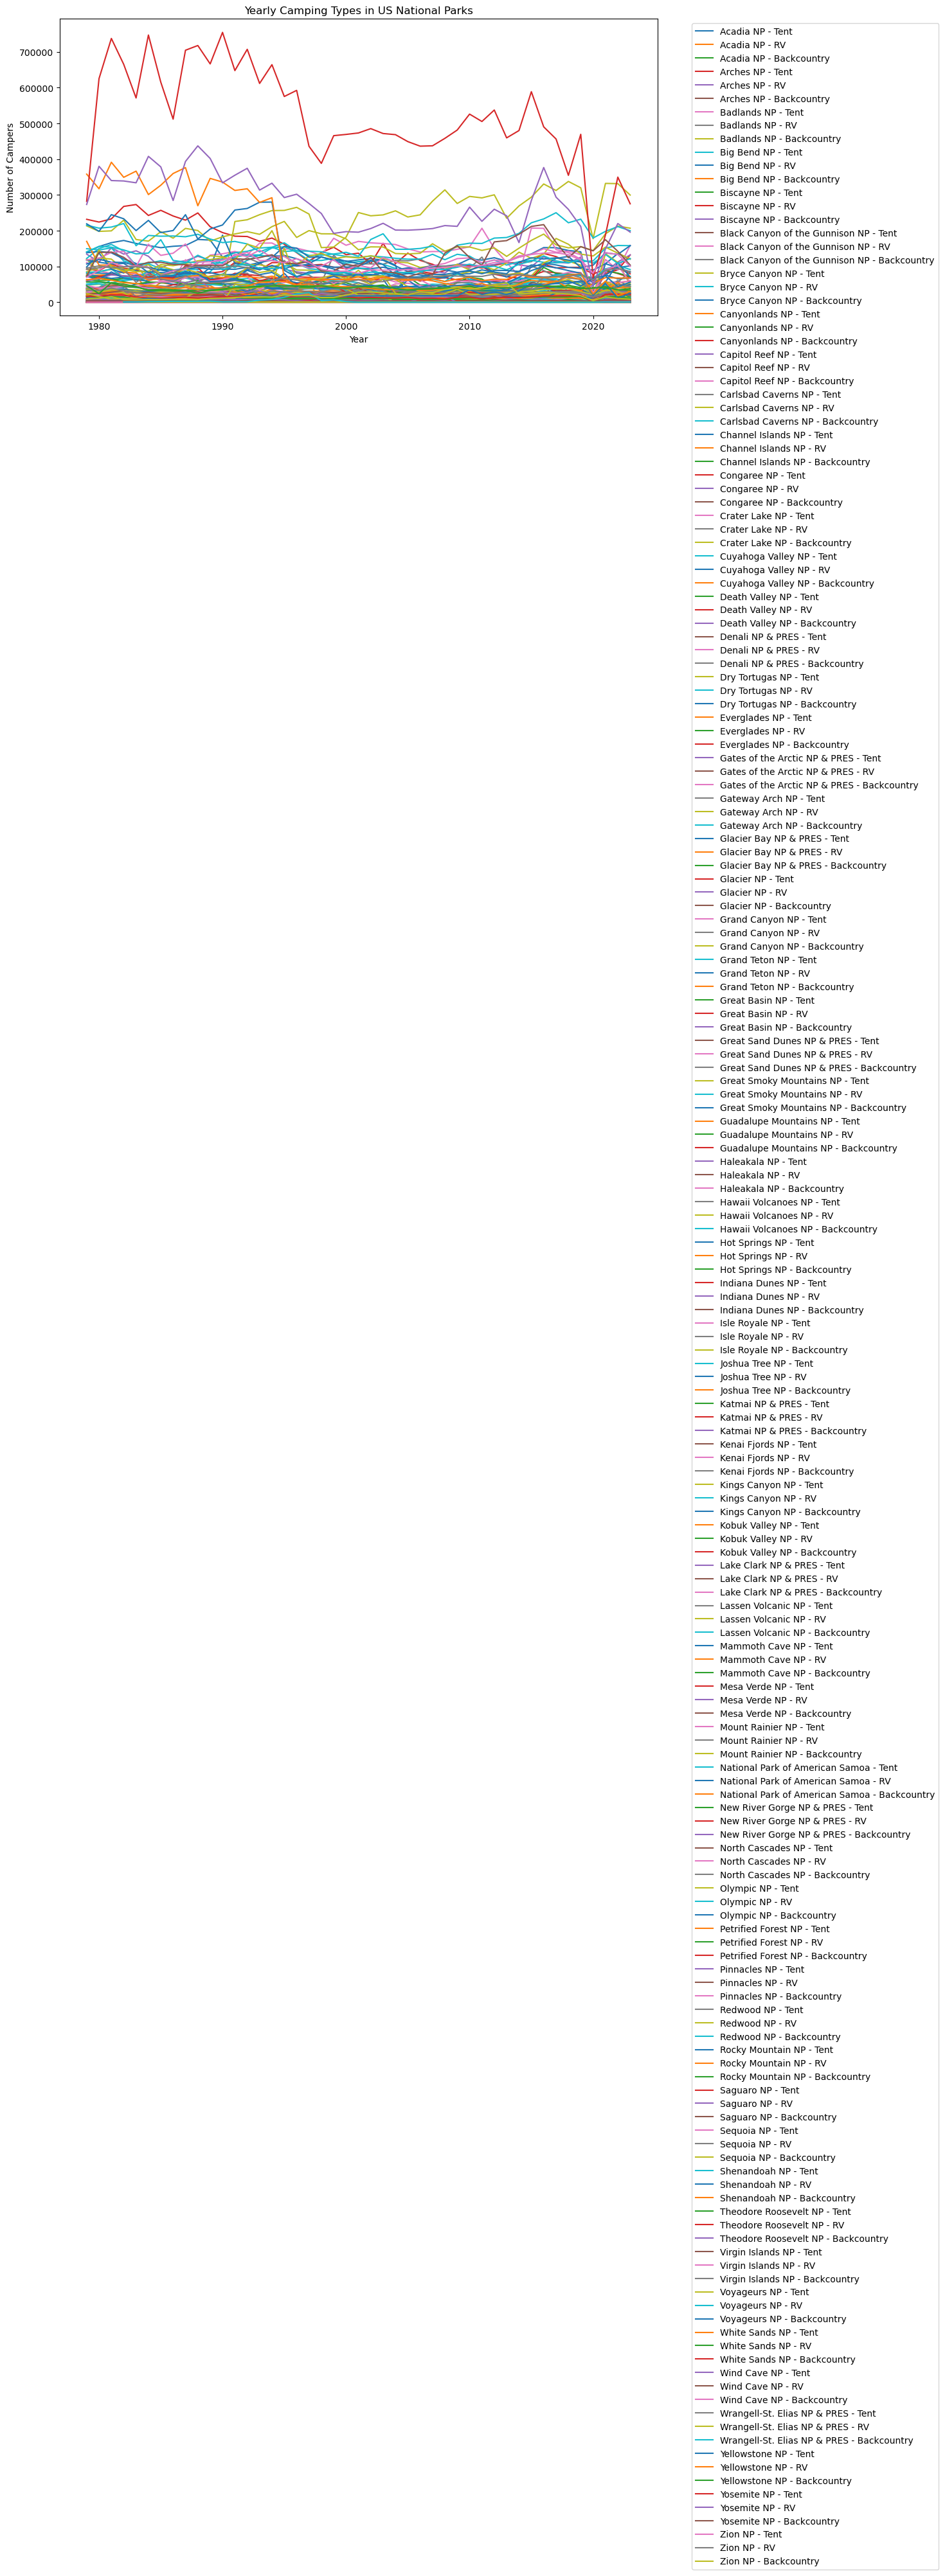

In [15]:
# is there a type of camper that is more popular in certain parks or regions?
camper_data = data.groupby(['ParkName', 'Year'])[['TentCampers', 'RVCampers', 'Backcountry']].sum().reset_index()
# camper_data

# plot
plt.figure(figsize=(12, 6))
for park in camper_data['ParkName'].unique():
    park_data = camper_data[camper_data['ParkName'] == park]
    plt.plot(park_data['Year'], park_data['TentCampers'], label=f'{park} - Tent')  
    plt.plot(park_data['Year'], park_data['RVCampers'], label=f'{park} - RV')  
    plt.plot(park_data['Year'], park_data['Backcountry'], label=f'{park} - Backcountry')
plt.xlabel('Year')
plt.ylabel('Number of Campers')
plt.title('Yearly Camping Types in US National Parks')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [3]:
# test comment